In [2]:
print("teste")
print("Ambiente funcionando")

teste
Ambiente funcionando


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
import sys
print(sys.executable)

d:\03_ESTUDOS\Data_Analytics_Alura\.venv\Scripts\python.exe


In [4]:
df = pd.read_csv('../dados/raw/vendas_brutas.csv')
df.head()

,data,produto,categoria,valor,quantidade
0,2026-01-01,Notebook,Eletronicos,3500,1
1,2026-01-02,Mouse,Eletronicos,100,2
2,2026-01-03,Cadeira,Móveis,800,1
3,2026-01-04,Teclado,Eletronicos,200,1
4,2026-01-05,Mesa,Móveis,1200,1


In [5]:
df['data'] = pd.to_datetime(df['data'])

df['faturamento'] = df['valor'] * df['quantidade']

df

,data,produto,categoria,valor,quantidade,faturamento
0,2026-01-01,Notebook,Eletronicos,3500,1,3500
1,2026-01-02,Mouse,Eletronicos,100,2,200
2,2026-01-03,Cadeira,Móveis,800,1,800
3,2026-01-04,Teclado,Eletronicos,200,1,200
4,2026-01-05,Mesa,Móveis,1200,1,1200
5,2026-01-06,Monitor,Eletronicos,1500,1,1500
6,2026-01-07,Luminária,Casa,150,3,450
7,2026-01-08,Sofá,Móveis,2500,1,2500
8,2026-01-09,Fone,Eletronicos,300,2,600
9,2026-01-10,Tapete,Casa,400,1,400


In [7]:
faturamento_total = df['faturamento'].sum()
faturamento_total

np.int64(11350)

In [8]:
faturamento_categoria = df.groupby('categoria')['faturamento'].sum()

faturamento_categoria

categoria
Casa            850
Eletronicos    6000
Móveis         4500
Name: faturamento, dtype: int64

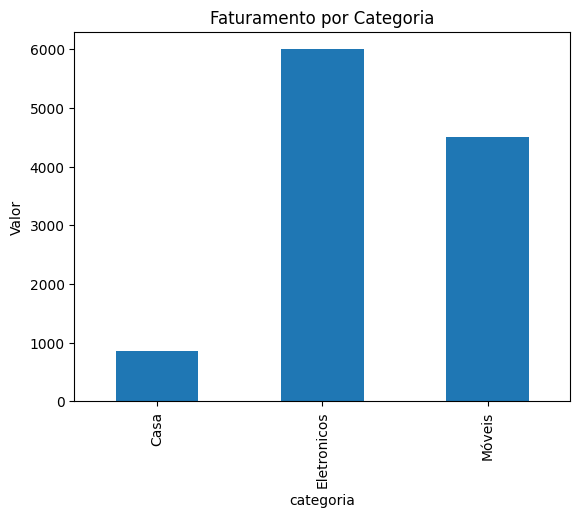

In [9]:
faturamento_categoria.plot(kind='bar')
plt.title('Faturamento por Categoria')
plt.ylabel('Valor')
plt.show()

In [10]:
ticket_medio = df['faturamento'].sum() / df['quantidade'].sum()
ticket_medio

np.float64(810.7142857142857)

In [11]:
df.groupby('categoria')['faturamento'].sum() / df['faturamento'].sum()

categoria
Casa           0.074890
Eletronicos    0.528634
Móveis         0.396476
Name: faturamento, dtype: float64

In [12]:
df[['produto', 'faturamento']].sort_values(by='faturamento', ascending=False)

,produto,faturamento
0,Notebook,3500
7,Sofá,2500
5,Monitor,1500
4,Mesa,1200
2,Cadeira,800
8,Fone,600
6,Luminária,450
9,Tapete,400
1,Mouse,200
3,Teclado,200


In [13]:
faturamento_atual = df['faturamento'].sum()
faturamento_combo = faturamento_atual * 1.15

faturamento_atual, faturamento_combo

(np.int64(11350), np.float64(13052.499999999998))

In [14]:
cenarios = {
    'Atual': faturamento_atual,
    'Com Combos (+15%)': faturamento_combo
}

import pandas as pd
pd.Series(cenarios)

Atual                11350.0
Com Combos (+15%)    13052.5
dtype: float64

In [15]:
# cenário atual
faturamento = 11350
margem = 0.30  # 30%
lucro = faturamento * margem

# cenário com combo
faturamento_combo = faturamento * 1.15  # +15% receita
margem_reduzida = 0.25  # margem menor
lucro_combo = faturamento_combo * margem_reduzida

lucro, lucro_combo

(3405.0, 3263.1249999999995)

In [16]:
plt.savefig('../outputs/faturamento_categoria.png')

<Figure size 640x480 with 0 Axes>